In [2]:
import pandas as pd

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
stk_data=pd.read_csv("Tatacoffee13_21.csv",parse_dates=['Date'],index_col='Date')

In [8]:
stk_data

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [10]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2225 entries, 2013-01-01 to 2021-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2225 non-null   float64
 1   High    2225 non-null   float64
 2   Low     2225 non-null   float64
 3   Close   2225 non-null   float64
dtypes: float64(4)
memory usage: 86.9 KB


In [12]:
column="Close"

In [14]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[[column]])

In [16]:
training_size=round(len(data1)*0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [66]:
orders=[(0,0,0),(0,0,1),(2,0,1),(1,1,1)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(X_train, order=i, seasonal_order=(1,0,1,12))
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(len(X_train), len(data1)-1)
    #print(y_pred)
    print("Order={}".format(i))
    from stockFunctions import rmsemape
    rmsemape(y_test,y_pred)
    print("*******")

C:\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order=(0, 0, 0)
RMSE-Testset: 0.05091832932388739
maPe-Testset: 190480053361.6092
*******
Order=(0, 0, 1)
RMSE-Testset: 0.05035825030472018
maPe-Testset: 199860993030.05106
*******
Order=(2, 0, 1)
RMSE-Testset: 0.05619220407740343
maPe-Testset: 110010550435.24718
*******
Order=(1, 1, 1)
RMSE-Testset: 0.0542830787560458
maPe-Testset: 109851492382.03871
*******


C:\Anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


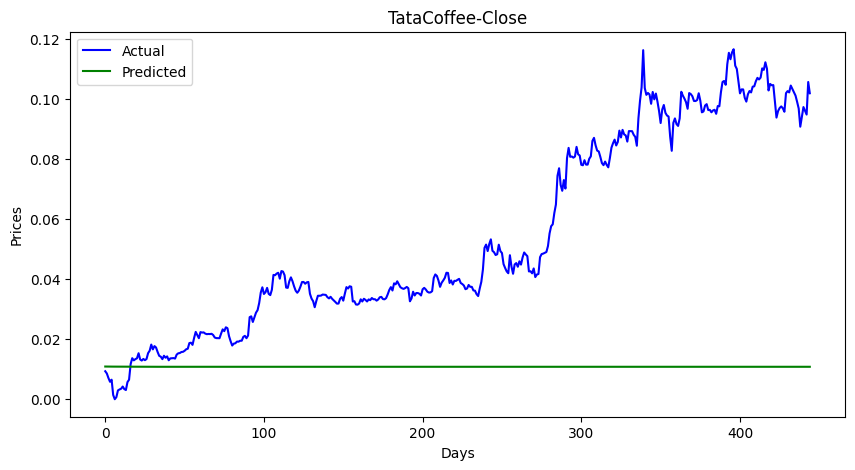

In [70]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [72]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [74]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

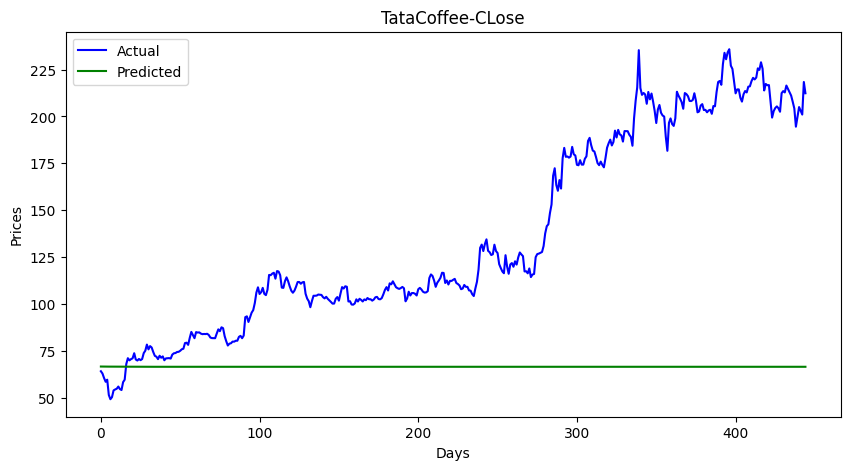

In [76]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [78]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 86.787786315166
maPe-Testset: 0.4427356979792531


In [80]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [82]:
forecast

array([0.01080489, 0.01080489, 0.01080489, 0.01080489])

In [84]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [86]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [88]:
forecast_stock_price_test_oriF

,Closefore
0,66.674851
1,66.674851
2,66.674851
3,66.674851
